In [4]:
import numpy as np
import matplotlib.pyplot as plt

IMG_H, IMG_W = 120, 180
POP_SIZE = 100 # Changed from 50 to 100

# Funciones auxiliares
def make_random_image(h=IMG_H, w=IMG_W, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return rng.integers(0,256, size=(h,w,3), dtype=np.uint8)

def show_image(ax, img, title=None):
    ax.imshow(img.astype(np.uint8))
    ax.axis('off')
    if title is not None:
        ax.set_title(title, fontsize=10)

def initialize_population(pop_size=POP_SIZE, h=IMG_H, w=IMG_W, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return rng.integers(0,256, size=(pop_size,h,w,3), dtype=np.uint8)

def mse_batch(pop, target):
    diff = pop.astype(np.int32) - target.astype(np.int32)
    mse = np.mean(diff*diff, axis=(1,2,3))
    return mse

In [5]:
# Operadores y bucle evolutivo
def tournament_select(pop, mse, k=3, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = pop.shape[0]
    idxs = rng.integers(0, N, size=(N, k))
    selected = []
    for row in idxs:
        best = row[np.argmin(mse[row])]
        selected.append(best)
    return np.array(selected, dtype=int)

def uniform_crossover(parent_a, parent_b, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    mask = rng.random(parent_a.shape) < 0.5
    child = np.where(mask, parent_a, parent_b).astype(np.uint8)
    return child

def mutate_image(img, mutation_prob_pixel=1e-3, mutation_std=15, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    img = img.astype(np.int32)
    mask = rng.random(img.shape) < mutation_prob_pixel
    if not mask.any():
        return img.astype(np.uint8)
    noise = rng.normal(loc=0.0, scale=mutation_std, size=img.shape).astype(np.int32)
    img[mask] += noise[mask]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def evolve(pop, target, max_gens=6000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = pop.shape[0]
    history = []
    mse = mse_batch(pop, target)
    best_idx = int(np.argmin(mse))
    history.append(mse[best_idx])
    for gen in range(1, max_gens+1):
        sel_idxs = tournament_select(pop, mse, k=3, rng=rng)
        parents = pop[sel_idxs]
        offspring = np.empty_like(parents)
        for i in range(0, N, 2):
            a = parents[i]
            b = parents[i+1 if i+1<N else 0]
            if rng.random() < 0.9:
                child1 = uniform_crossover(a, b, rng=rng)
                child2 = uniform_crossover(b, a, rng=rng)
            else:
                child1 = a.copy(); child2 = b.copy()
            child1 = mutate_image(child1, mutation_prob_pixel=1e-3, mutation_std=15, rng=rng)
            child2 = mutate_image(child2, mutation_prob_pixel=1e-3, mutation_std=15, rng=rng)
            offspring[i] = child1
            if i+1 < N:
                offspring[i+1] = child2
        pop = offspring
        mse = mse_batch(pop, target)
        best_idx = int(np.argmin(mse))
        history.append(mse[best_idx])
        if gen % 10 == 0:
            print(f'Gen {gen}: best MSE = {history[-1]:.2f}')
        if mse[best_idx] == 0:
            print('Perfect match found at generation', gen)
            break
    best_idx = int(np.argmin(mse))
    return pop, np.array(history), pop[best_idx], mse[best_idx]


array([[[ 26,   4,   1],
        [ 22,   2,   2],
        [ 20,   1,   1],
        ...,
        [106,  44,  44],
        [ 56,   1,   2],
        [ 43,   8,   8]],

       [[ 36,   8,   2],
        [ 31,   4,   1],
        [ 22,   2,   0],
        ...,
        [111,  76,  73],
        [ 23,   0,   0],
        [ 59,  35,  35]],

       [[ 41,   7,   3],
        [ 39,   6,   3],
        [ 35,   6,   3],
        ...,
        [179, 156, 152],
        [ 87,  62,  58],
        [173, 154, 144]],

       ...,

       [[  0,   1,   1],
        [  8,   3,   2],
        [ 16,   6,   4],
        ...,
        [175,  66,  17],
        [144,  51,  18],
        [ 73,  10,   8]],

       [[  1,   1,   0],
        [ 10,   4,   3],
        [ 19,   7,   4],
        ...,
        [185,  49,  25],
        [118,  24,  20],
        [ 48,   8,   8]],

       [[  4,   2,   1],
        [ 17,   5,   4],
        [ 18,   5,   4],
        ...,
        [172,  23,  11],
        [102,  19,  11],
        [ 59,  16,  13]]], dtype=uint8)
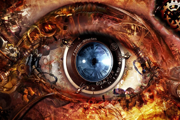

Población y target creados. Ejecutando evolución...
Gen 10: best MSE = 11571.66
Gen 20: best MSE = 11301.37
Gen 30: best MSE = 11093.81
Gen 40: best MSE = 10920.38
Gen 50: best MSE = 10781.87
Gen 60: best MSE = 10681.25
Gen 70: best MSE = 10570.52
Gen 80: best MSE = 10488.28
Gen 90: best MSE = 10415.46
Gen 100: best MSE = 10368.61
Gen 110: best MSE = 10317.46
Gen 120: best MSE = 10284.39
Gen 130: best MSE = 10254.43
Gen 140: best MSE = 10231.61
Gen 150: best MSE = 10213.61
Gen 160: best MSE = 10195.86
Gen 170: best MSE = 10182.26
Gen 180: best MSE = 10170.14
Gen 190: best MSE = 10158.52
Gen 200: best MSE = 10146.36
Gen 210: best MSE = 10134.72
Gen 220: best MSE = 10124.59
Gen 230: best MSE = 10113.66
Gen 240: best MSE = 10101.30
Gen 250: best MSE = 10090.06
Gen 260: best MSE = 10079.59
Gen 270: best MSE = 10069.49
Gen 280: best MSE = 10058.31
Gen 290: best MSE = 10045.85
Gen 300: best MSE = 10036.24
Gen 310: best MSE = 10026.07
Gen 320: best MSE = 10014.45
Gen 330: best MSE = 10004.11


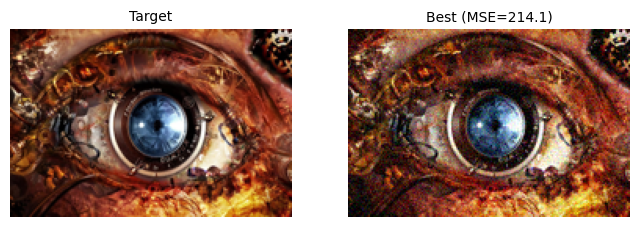

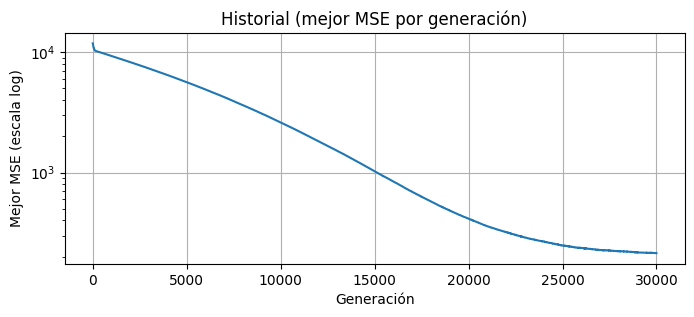

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image # Importar la librería Pillow

# Uso: crear target, inicializar población y ejecutar
rng = np.random.default_rng(42)

try:
    img_path = 'dog.jpg'

    # 2. Abre la imagen
    target_pil = Image.open(img_path).convert('RGB')
    target = np.array(target_pil.resize((IMG_W, IMG_H)))
    # 3. (Opcional) Muestra la imagen para que el profe vea que se leyó correctamente
    display(target)

except FileNotFoundError:
    print(f"Advertencia: No se encontró la imagen '{img_path}'. Se usará una imagen aleatoria como target.")
    target = make_random_image(rng=rng)
# ------------------------------------------------------------------

pop = initialize_population(rng=rng)

print('Población y target creados. Ejecutando evolución...')
pop, history, best_img, best_mse = evolve(pop, target, max_gens=30000, rng=rng) # Changed max_gens from 10000 to 30000

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(8,4))
show_image(ax[0], target, title='Target')
show_image(ax[1], best_img, title=f'Best (MSE={best_mse:.1f})')
plt.show()

plt.figure(figsize=(8,3))
plt.plot(history)
plt.yscale('log')
plt.title('Historial (mejor MSE por generación)')
plt.xlabel('Generación')
plt.ylabel('Mejor MSE (escala log)')
plt.grid(True)
plt.show()